# Audit label + grafici a torta (AMBL/Duke radiomic)

In [55]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from IPython.display import display

## Configurazione (marker, alias, path dataset)

In [56]:
# Configuro: marker + alias + dataset
MARKERS = ["ER", "PR", "HER2", "KI67", "isTN"]

MARKER_ALIASES = {
    "ER":   ["ER [SII]", "ER", "ER [%]", "ER_SII"],
    "PR":   ["PR [SII]", "PR", "PR [%]", "PR_SII"],
    "HER2": ["HER2 [SII]", "HER2", "HER2_SII", "HER2_class", "HER2 Class"],
    "KI67": ["KI67 [%]", "KI67", "Ki67", "Ki-67", "Ki67 [%]"],
    "isTN": ["isTN", "isTN ", "TN", "IsTN", "is_tn"]
}

DATASET_PATH = Path("/Users/francesco/Tesi/BC-ML4/dataset/cleaned")

datasets = {
   'duke_lesions_radiomic' : DATASET_PATH / 'duke_lesions_radiomic_medsam.csv'
}

## Funzioni di supporto (selezione colonna, distribuzioni, audit, pie chart)

In [57]:
def pick_column(df: pd.DataFrame, marker: str):
    """Ritorna il nome colonna effettivo nel df per quel marker, oppure None."""
    for cand in MARKER_ALIASES.get(marker, []):
        if cand in df.columns:
            return cand
    return None


def value_distribution(series: pd.Series, top_k: int = 15) -> pd.DataFrame:
    """
    Tabella distribuzione:
    - rende NaN esplicito come 'NaN'
    - calcola count e percentuale
    - se troppi valori, tiene top_k e raggruppa il resto in 'ALTRO'
    """
    s = series.astype("object")
    s = s.where(pd.notna(s), other="NaN")

    vc = s.value_counts(dropna=False)

    dist = vc.reset_index()
    dist.columns = ["valore", "count"]
    dist["percentuale"] = (dist["count"] / dist["count"].sum() * 100).round(2)

    if len(dist) > top_k:
        head = dist.head(top_k).copy()
        tail = dist.iloc[top_k:].copy()
        altro = pd.DataFrame([{
            "valore": "ALTRO",
            "count": int(tail["count"].sum()),
            "percentuale": float(tail["percentuale"].sum())
        }])
        dist = pd.concat([head, altro], ignore_index=True)

    return dist


def pie_distribution(series: pd.Series, top_k: int = 8) -> pd.DataFrame:
    """Distribuzione per pie chart (NaN esplicito + ALTRO)."""
    dist = value_distribution(series, top_k=top_k)
    return dist[["valore", "count"]]


def audit_labels(datasets: dict, markers=MARKERS, top_k: int = 12) -> pd.DataFrame:
    """Tabella audit con legenda, una riga per dataset×marker."""
    rows = []
    for ds_name, path in datasets.items():
        df = pd.read_csv(path)

        for marker in markers:
            col = pick_column(df, marker)

            if col is None:
                rows.append({
                    "dataset": ds_name,
                    "marker": marker,
                    "colonna_usata": None,
                    "presente": False,
                    "n_tot": np.nan,
                    "n_nan": np.nan,
                    "n_unici": np.nan,
                    "valori_top": np.nan
                })
                continue

            s = df[col]
            n_tot = int(len(s))
            n_nan = int(s.isna().sum())
            n_unici = int(s.dropna().nunique())

            dist = value_distribution(s, top_k=top_k)

            # formato chiaro: valore:conteggio (percentuale%)
            valori_top = "; ".join([
                f"{row.valore}:{int(row.count)} ({row.percentuale}%)"
                for row in dist.itertuples(index=False)
            ])

            rows.append({
                "dataset": ds_name,
                "marker": marker,
                "colonna_usata": col,
                "presente": True,
                "n_tot": n_tot,
                "n_nan": n_nan,
                "n_unici": n_unici,
                "valori_top": valori_top
            })

    return pd.DataFrame(rows)


def plot_pies_for_dataset(csv_path: Path, dataset_name: str, markers=MARKERS, top_k: int = 8):
    """Grafici a torta per ogni marker del dataset."""
    df = pd.read_csv(csv_path)

    for marker in markers:
        col = pick_column(df, marker)
        if col is None:
            continue

        dist = pie_distribution(df[col], top_k=top_k)

        labels = dist["valore"].astype(str).tolist()
        sizes = dist["count"].astype(int).tolist()

        plt.figure(figsize=(7, 5))
        wedges, texts, autotexts = plt.pie(
            sizes,
            startangle=90,
            autopct=lambda p: f"{p:.1f}%" if p >= 3 else ""
        )
        plt.title(f"{dataset_name} — {marker} (colonna: {col})")

        # legenda esterna (più leggibile)
        legend_labels = [f"{lab} = {cnt}" for lab, cnt in zip(labels, sizes)]
        plt.legend(
            wedges,
            legend_labels,
            title="Valore = conteggio",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False
        )

        plt.tight_layout()
        plt.show()

## 1) Audit tabellare (con legenda)

In [58]:
audit_df = audit_labels(datasets, top_k=12)
display(audit_df)

,dataset,marker,colonna_usata,presente,n_tot,n_nan,n_unici,valori_top
0,duke_lesions_radiomic,ER,ER,True,291.0,0.0,2.0,1:168 (57.73%); 0:123 (42.27%)
1,duke_lesions_radiomic,PR,PR,True,291.0,0.0,2.0,0:157 (53.95%); 1:134 (46.05%)
2,duke_lesions_radiomic,HER2,HER2,True,291.0,0.0,2.0,0:208 (71.48%); 1:83 (28.52%)
3,duke_lesions_radiomic,KI67,None,False,NaN,NaN,NaN,NaN
4,duke_lesions_radiomic,isTN,None,False,NaN,NaN,NaN,NaN


# Grafici a torta (distribuzione label per marker)

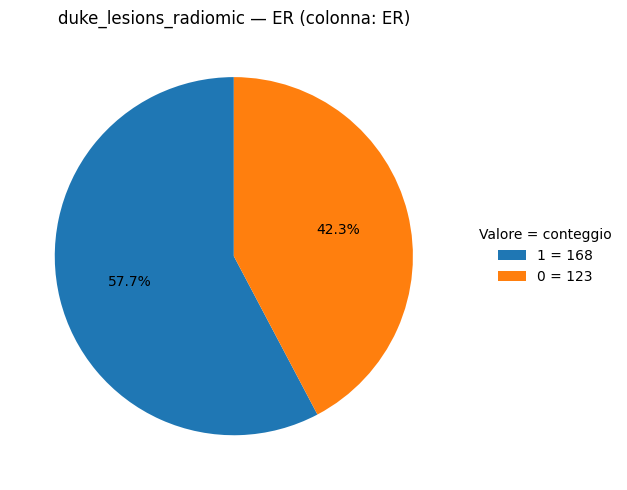

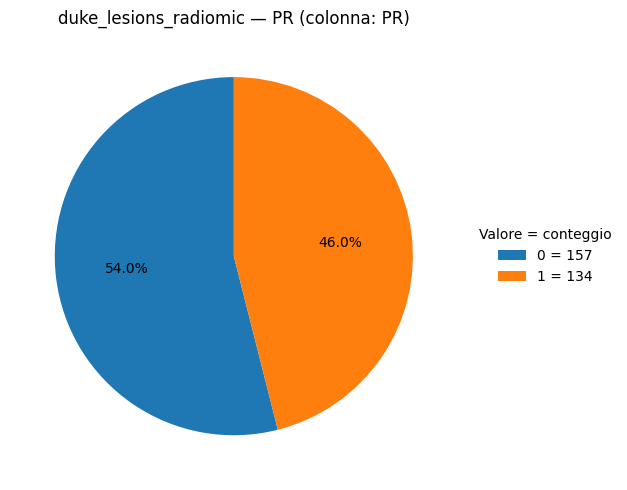

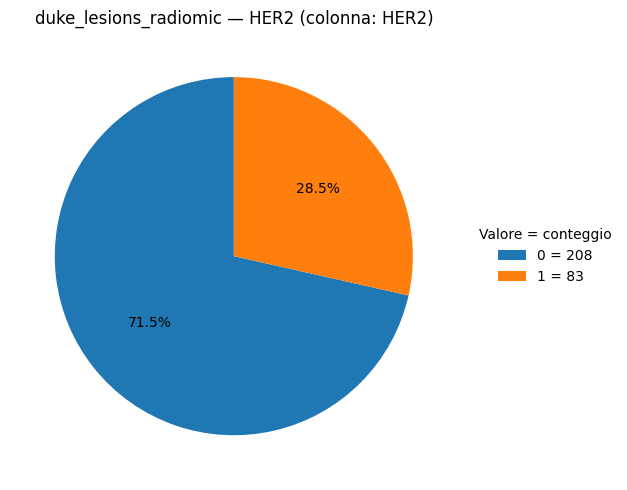

In [59]:
for name, path in datasets.items():
    plot_pies_for_dataset(path, name, top_k=8)